TRAINING + TESTING

This will include:

Loading dataset
Splitting
Scaling
Training 3 models
Confusion matrix
Feature importance

1. Loading Dataset

In [22]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

df = pd.read_csv('cleaned.csv')

df.head()

,Gender,Age,Married,Number of Dependents,Latitude,Longitude,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,...,Churn Reason_Network reliability,Churn Reason_Poor expertise of online support,Churn Reason_Poor expertise of phone support,Churn Reason_Price too high,Churn Reason_Product dissatisfaction,Churn Reason_Service dissatisfaction,age_group,avg_monthly_spend,spend_change,high_bill
0,1,37,1,0,34.83,-119.00,2,9,1,42.39,...,False,False,False,False,False,False,Adult,59.33,6.27,0
1,0,46,0,0,34.16,-118.20,0,9,1,10.69,...,False,False,False,False,False,False,Adult,54.24,-50.24,0
2,0,50,0,0,33.65,-117.92,0,4,1,33.65,...,False,False,False,False,False,False,Adult,56.17,17.73,1
3,0,78,1,0,38.01,-122.12,1,13,1,27.82,...,False,False,False,False,True,False,Senior,88.42,9.58,1
4,1,75,1,0,34.23,-119.08,3,3,1,7.38,...,True,False,False,False,False,False,Senior,66.85,17.05,1


In [23]:
df['Customer Status'].unique()

array([0, 1, 2])

2. Train-Test Split

In any supervised machine-learning, we must separate:

Features (X): the information used to make predictions
Target (y): the information we want the model to predict

In [24]:
df = pd.get_dummies(df, drop_first=True) #Initially, One-hot encoding should be applied, else the model will not understand the categorical data.

In [25]:
X = df.drop(['Customer Status'], axis=1) # Input- All columns except target  
y = df['Customer Status']   #output = churn (0/1)

In [26]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2          #80% data- training & 20% data- testing & random_state=42 ensures repeatability
)

3. Feature Scaling (Important for Logistic Regression)

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

BALANCING IMBALNCES DATASET

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

MODEL 1 — LOGISTIC REGRESSION

It draws a line (or hyperplane) that best separates two classes.

In [29]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

print("\nClassification Report:\n", classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 0.9496096522356281
[[949   8   3]
 [ 38 317  11]
 [  6   5  72]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       960
           1       0.96      0.87      0.91       366
           2       0.84      0.87      0.85        83

    accuracy                           0.95      1409
   macro avg       0.92      0.91      0.91      1409
weighted avg       0.95      0.95      0.95      1409



MODEL 2 — Knn (k nearest neighbours)

In [30]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_knn))
print(confusion_matrix(y_test, pred_knn))
print("trainscore:", knn.score(X_train, y_train))
print(classification_report(y_test, pred_knn))

Accuracy: 0.9027679205110007
[[926  14  20]
 [ 43 316   7]
 [ 44   9  30]]
trainscore: 0.9364572239971601
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       960
           1       0.93      0.86      0.90       366
           2       0.53      0.36      0.43        83

    accuracy                           0.90      1409
   macro avg       0.79      0.73      0.75      1409
weighted avg       0.90      0.90      0.90      1409



HYPERPARAMETER TUNING FOR BEST OF K

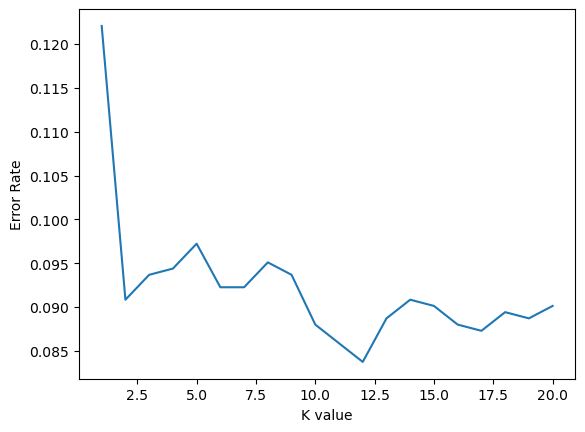

In [31]:
error_rate = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test))

plt.plot(range(1,21), error_rate)
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.show()

In [32]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [33]:
y_pred=knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))


[[926  14  20]
 [ 43 316   7]
 [ 44   9  30]]


In [34]:
knn.score(X_train, y_train)


0.9364572239971601

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9027679205110007


MODEL 3 - SVM (Support Vector Machine)

Support Vector Machine (SVM) is a supervised machine-learning algorithm used to find the best possible boundary (hyperplane) that separates classes with the maximum margin.

SVM uses support vectors (critical data points near the boundary) to create that line.

In [36]:

# Create SVM model using RBF kernel (most common)
svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))
print(confusion_matrix(y_test, svm_pred))
print('svm',svm.score(X_train,y_train))

Accuracy: 0.9382540809084458
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       960
           1       0.99      0.85      0.91       366
           2       0.79      0.71      0.75        83

    accuracy                           0.94      1409
   macro avg       0.90      0.85      0.87      1409
weighted avg       0.94      0.94      0.94      1409

[[953   1   6]
 [ 46 310  10]
 [ 21   3  59]]
svm 0.9513667021654242


Confusion Matrices (All Models)

A confusion matrix is a table that shows how many:

Correct predictions the model made
Wrong predictions the model made

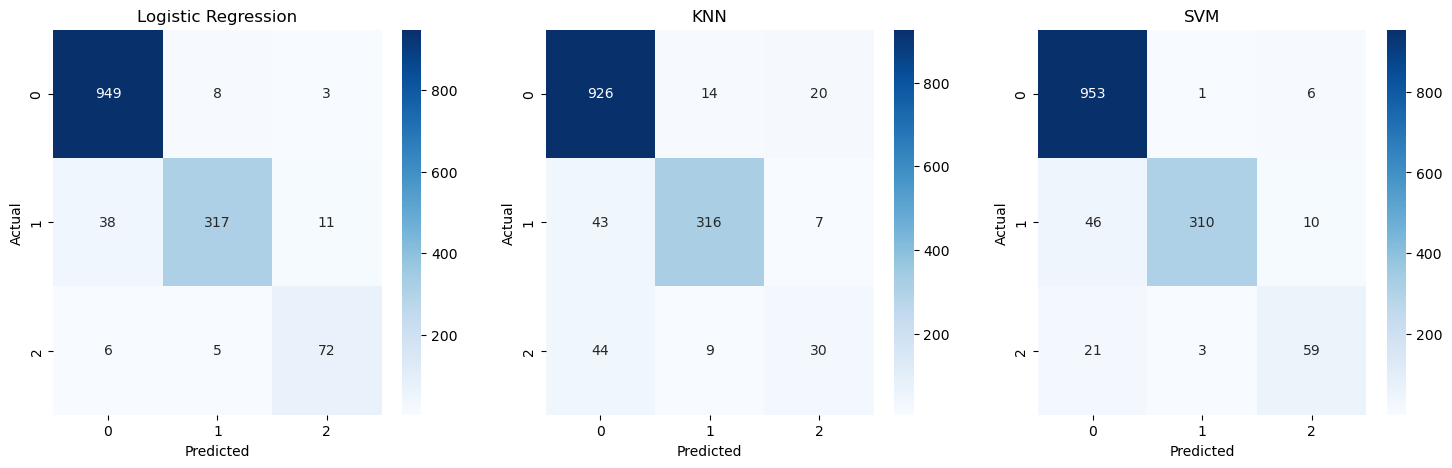

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [pred_lr,y_pred,svm_pred]
titles = ["Logistic Regression", "KNN","SVM"]

for i, model in enumerate(models):
    cm = confusion_matrix(y_test, model)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.show()

MODEL 4— DECISION TREE

A model that splits data into branches based on conditions.

In [38]:
dt = DecisionTreeClassifier(criterion="gini", max_depth=5,random_state=42)# Create XGB model
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print("trainscore:", dt.score(X_train, y_train))
print(confusion_matrix(y_test, pred_dt))
print("\nClassification Report:\n", classification_report(y_test, pred_dt))

Decision Tree Accuracy: 0.9467707594038325
trainscore: 0.9597089101881434
[[946  14   0]
 [ 37 319  10]
 [  0  14  69]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       960
           1       0.92      0.87      0.89       366
           2       0.87      0.83      0.85        83

    accuracy                           0.95      1409
   macro avg       0.92      0.90      0.91      1409
weighted avg       0.95      0.95      0.95      1409



MODEL 5: Random Forest

A collection of many decision trees → ensemble method.Each tree is trained on different parts of data (bootstrapping).Final prediction = majority vote from all trees.

In [39]:
rf = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=5)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print("trainscore:", rf.score(X_train, y_train))
print(confusion_matrix(y_test, pred_rf))
print("\nClassification Report:\n", classification_report(y_test, pred_rf))

Random Forest Accuracy: 0.9559971611071683
trainscore: 0.9572239971600994
[[960   0   0]
 [ 44 310  12]
 [  2   4  77]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       960
           1       0.99      0.85      0.91       366
           2       0.87      0.93      0.90        83

    accuracy                           0.96      1409
   macro avg       0.94      0.92      0.93      1409
weighted avg       0.96      0.96      0.95      1409



MODEL 6 — GRADIENT BOOSTING

Gradient Boosting is a strong ensemble machine-learning model that builds MANY small weak models (usually small decision trees) one after another, and each new model corrects the mistakes of the previous one.

Gradient Boosting = Learn from errors step-by-step.

In [40]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred_gb))
print(confusion_matrix(y_test, pred_gb))
print("trainscore:", gb.score(X_train, y_train))
print("\nClassification Report:\n", classification_report(y_test, pred_gb))

Gradient Boosting Accuracy: 0.9545777146912704
[[951   9   0]
 [ 37 318  11]
 [  0   7  76]]
trainscore: 0.9801206957756479

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       960
           1       0.95      0.87      0.91       366
           2       0.87      0.92      0.89        83

    accuracy                           0.95      1409
   macro avg       0.93      0.93      0.93      1409
weighted avg       0.95      0.95      0.95      1409



MODEL 7 - XGB

In [41]:
# Create XGB model
xgb = XGBClassifier(
    n_estimators=200,       # number of trees
    learning_rate=0.05,    # step size
    max_depth=5,           # depth of each tree
    subsample=0.8,         # % of rows used per tree
    colsample_bytree=0.8,  # % of features per tree
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("trainscore:", xgb.score(X_train, y_train))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9567068843151171
[[952   8   0]
 [ 38 318  10]
 [  0   5  78]]
trainscore: 0.9898828541001065

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       960
           1       0.96      0.87      0.91       366
           2       0.89      0.94      0.91        83

    accuracy                           0.96      1409
   macro avg       0.94      0.93      0.93      1409
weighted avg       0.96      0.96      0.96      1409



Final Comparison

In [42]:

results = {
    'Logistic Regression': accuracy_score(y_test, pred_lr),
   'Decision Tree': accuracy_score(y_test, pred_dt),
    'SVM': accuracy_score(y_test, svm_pred),
    'KNN': accuracy_score(y_test, y_pred),
    'Gradient Boosting': accuracy_score(y_test, pred_gb),
    'Random Forest': accuracy_score(y_test, pred_rf),
    'Xgb': accuracy_score(y_test, y_pred),
    

}

pd.DataFrame(results, index=['Accuracy'])

,Logistic Regression,Decision Tree,SVM,KNN,Gradient Boosting,Random Forest,Xgb
Accuracy,0.94961,0.946771,0.938254,0.956707,0.954578,0.955997,0.956707


ABOVE are Best Accuracy Models